In [ ]:
### IMPORT ###
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Input
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, Activation, MaxPooling2D,
    GlobalAveragePooling2D, Dense, Dropout, Add, Flatten)

from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall, AUC
import numpy as np
import pathlib
import random


In [10]:
#CHECK GPU
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [11]:
#### CONSTANTS ###
train_data_path = "../dataset_train"
test_data_path = "../dataset_test"
weigths_path = "../weights"

In [ ]:
### HELPERS FUNCTIONS ###
def load_custom_multiclass_dataset(data_path, batch_size=32, img_size=(200, 200), subset_ratio=1.0):
    """
    Custom dataset loader that works with a directory structure like:
    
    data_path/
        art/
            real/
                image1.jpg
                image2.jpg
                ...
            fake/
                image3.jpg
                image4.jpg
                ...
        animals/
            real/
                ...
            fake/
                ...
        faces/
            real/
                ...
            fake/
                ...
    
    The loader ignores the intermediate real/fake folders and uses the top-level folder
    (art, animals, or faces) as the label. It builds a one-hot encoded multiclass dataset.
    
    Parameters:
        data_path (str): Path to the dataset.
        batch_size (int): Number of images per batch.
        img_size (tuple): Target size for images.
        subset_ratio (float): Fraction of samples to use.
        
    Returns:
        A tf.data.Dataset yielding (image, label) pairs and the list of class names.
    """
    data_path = pathlib.Path(data_path)

    image_extensions = ["*.jpg", "*.jpeg", "*.png"]
    all_files = []
    for ext in image_extensions:
        all_files.extend(list(data_path.glob(f"*/*/{ext}")))
    
    all_files = [fp for fp in all_files if fp.is_file()]
    
    def get_category(file_path):
        rel_parts = file_path.relative_to(data_path).parts
        return rel_parts[0]
    
    categories = sorted(list({get_category(fp) for fp in all_files}))
    print("Detected categories:", categories)
    
    label_to_index = {cat: idx for idx, cat in enumerate(categories)}
    
    samples = []
    for fp in all_files:
        category = get_category(fp)
        label_index = label_to_index[category]
        samples.append((str(fp), label_index))
    
    random.shuffle(samples)
    if subset_ratio < 1.0:
        samples = samples[:int(len(samples) * subset_ratio)]
    
    file_paths, labels = zip(*samples)

    ds = tf.data.Dataset.from_tensor_slices((list(file_paths), list(labels)))
    
    def _load_and_preprocess(path, label):
        image = tf.io.read_file(path)

        image = tf.image.decode_image(image, channels=3, expand_animations=False)
        image = tf.image.resize(image, img_size)
        image = tf.cast(image, tf.float32) / 255.0  
        label = tf.one_hot(label, depth=len(categories))
        return image, label
    
    ds = ds.map(_load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    
    return ds, categories



def scale_images_to_unit_range(dataset):
    """
    Applies scaling to images in the dataset so that their pixel values are in the [0, 1] range.
    
    Parameters:
        dataset (tf.data.Dataset): A TensorFlow dataset where each element is a (image, label) pair.
        
    Returns:
        A new tf.data.Dataset with the images scaled to [0, 1].
    """
    def scaling_fn(image, label):
        image = tf.cast(image, tf.float32) / 255.0
        return image, label

    return dataset.map(scaling_fn)

# VISUALIZE TRAINING DATA
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # accuracy
    ax1.plot(history.history['accuracy'])
    ax1.plot(history.history['val_accuracy'])
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='lower right')

    # loss
    ax2.plot(history.history['loss'])
    ax2.plot(history.history['val_loss'])
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper right')

    plt.tight_layout()
    plt.show()
    

def plot_gradcam(model, image, class_index, last_conv_layer_name, alpha=0.4):
    """
    Generates and plots a Grad-CAM heatmap for a given image and class.

    Args:
        model: Trained Keras model.
        image: Input image as a NumPy array of shape (height, width, channels). 
               The image should be preprocessed (e.g., normalized) as needed.
        class_index: Integer index of the target class to visualize.
        last_conv_layer_name: String, name of the last convolutional layer in the model.
        alpha: Float, transparency factor for the heatmap overlay.
    """
    img_tensor = np.expand_dims(image, axis=0)

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    heatmap = heatmap.numpy()

    heatmap = np.uint8(255 * heatmap)
    heatmap = tf.image.resize(np.expand_dims(
        heatmap, axis=-1), (image.shape[0], image.shape[1])).numpy()
    heatmap = np.squeeze(heatmap)

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(image)
    ax[0].set_title('Original Imege')
    ax[0].axis('off')
    ax[1].imshow(image)
    ax[1].imshow(heatmap, cmap='jet', alpha=alpha)
    ax[1].set_title('Grad-CAM heatmap')
    ax[1].axis('off')
    plt.tight_layout()
    plt.show()
    

def compute_saliency_map(model, image, target_class=0):
    """
    Computes the saliency map for the given image and target class.

    Args:
        model: Trained Keras model.
        image: Input image as a NumPy array of shape (height, width, channels).
               Assumed to be preprocessed (e.g., normalized) as required by the model.
        target_class: Integer index for the target class.

    Returns:
        A NumPy array representing the saliency map.
    """
    img_tensor = tf.expand_dims(image, axis=0)
    img_tensor = tf.cast(img_tensor, tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        preds = model(img_tensor)
        score = preds[:, target_class]

    grads = tape.gradient(score, img_tensor)

    saliency = tf.reduce_max(tf.abs(grads), axis=-1)[0]
    return saliency.numpy()


def display_saliency_map(model, image, target_class=0):
    """
    Computes and displays the saliency map alongside the original image.
    
    Args:
        model: Trained Keras model.
        image: A single input image as a NumPy array.
        target_class: The index of the target class.
    """
    saliency = compute_saliency_map(model, image, target_class)

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(saliency, cmap='jet')
    plt.title("Saliency Map")
    plt.axis("off")

    plt.show()



def plot_images_by_category(dataset, class_names, num_per_class=2):
    """
    Plots a specified number of images from each category in the dataset.
    
    Parameters:
        dataset (tf.data.Dataset): The dataset containing image-label pairs
        class_names (list): List of class names
        num_per_class (int): Number of images to display per class
    """
    fig, axes = plt.subplots(len(class_names), num_per_class, figsize=(num_per_class*4, len(class_names)*4))
    
    images_by_class = {cls: [] for cls in range(len(class_names))}
    unbatched_ds = dataset.unbatch()
    
    for image, label in unbatched_ds:
        label_idx = np.argmax(label.numpy())
        if len(images_by_class[label_idx]) < num_per_class:
            images_by_class[label_idx].append(image.numpy())
        if all(len(imgs) >= num_per_class for imgs in images_by_class.values()):
            break

    for i, class_name in enumerate(class_names):
        for j in range(min(num_per_class, len(images_by_class[i]))):
            if len(class_names) > 1:
                ax = axes[i, j]
            else:
                ax = axes[j]
            
            ax.imshow(images_by_class[i][j])
            ax.set_title(f"{class_name}")
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()


In [13]:
batch_size = 32
img_size = (200, 200)


In [15]:

train_dataset, class_names = load_custom_multiclass_dataset(train_data_path, batch_size=batch_size, img_size=img_size, subset_ratio=0.3)
test_dataset, _ = load_custom_multiclass_dataset(test_data_path, batch_size=batch_size, img_size=img_size, subset_ratio=0.3)

print("Class names:", class_names)

Detected categories: ['animals', 'art', 'faces']
Detected categories: ['animals', 'art', 'faces']
Class names: ['animals', 'art', 'faces']


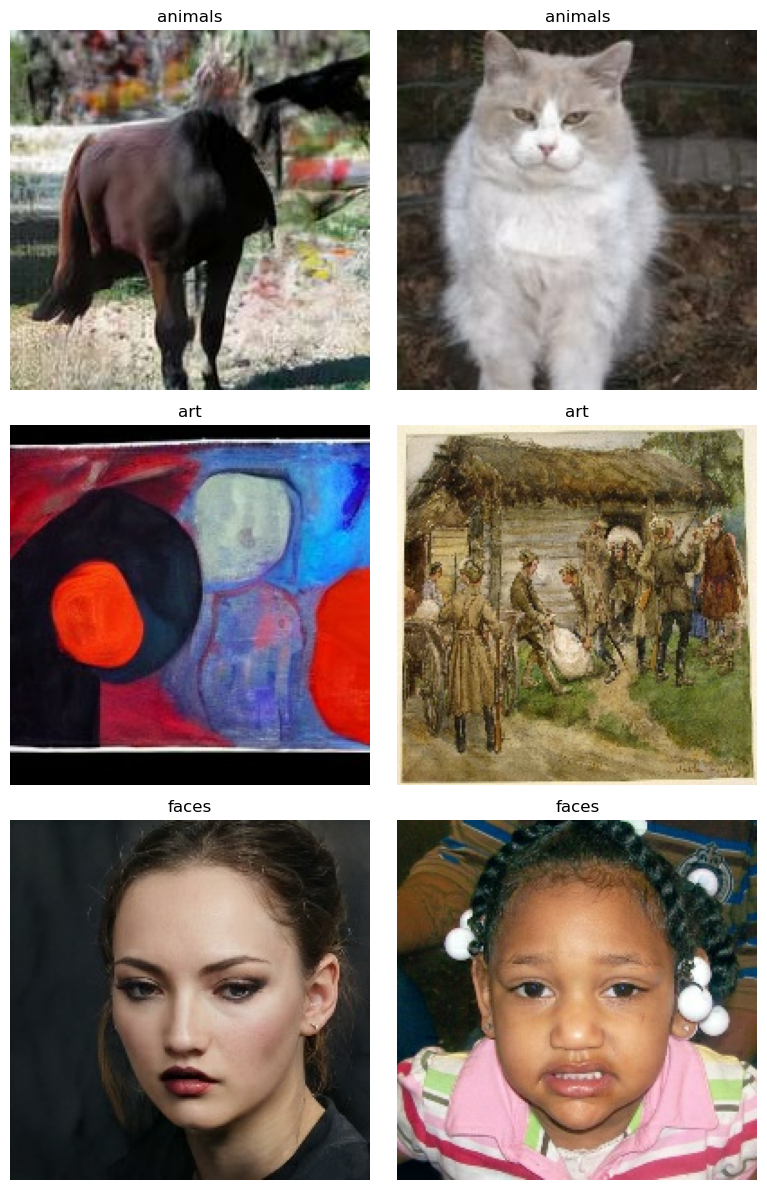

In [17]:
plot_images_by_category(train_dataset, class_names, num_per_class=2)

In [23]:
### Model 
input_shape = (200, 200, 3)
num_classes = len(class_names)

inputs = Input(shape=input_shape)

# 1st conv
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)

# 2nd conv
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)

# 3rd conv
#x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
#x = layers.BatchNormalization()(x)
#x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
#x = layers.BatchNormalization()(x)
#x = layers.MaxPooling2D((2, 2))(x)
#x = layers.Dropout(0.25)(x)

# 4th conv
#x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
#x = layers.BatchNormalization()(x)
#x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
#x = layers.BatchNormalization()(x)
#x = layers.MaxPooling2D((2, 2))(x)
#x = layers.Dropout(0.25)(x)

# flatten
x = layers.Flatten()(x)

# ffnn
x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(num_classes, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)

model.summary()


Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 200, 200, 3)]     0         
                                                                 
 conv2d_22 (Conv2D)          (None, 200, 200, 32)      896       
                                                                 
 batch_normalization_28 (Ba  (None, 200, 200, 32)      128       
 tchNormalization)                                               
                                                                 
 conv2d_23 (Conv2D)          (None, 200, 200, 32)      9248      
                                                                 
 batch_normalization_29 (Ba  (None, 200, 200, 32)      128       
 tchNormalization)                                               
                                                                 
 max_pooling2d_11 (MaxPooli  (None, 100, 100, 32)      0   

In [24]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

weights_path = "../weights"
os.makedirs(weights_path, exist_ok=True)

checkpoint = ModelCheckpoint(
    os.path.join(weights_path, 'decision_model.h5'),
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [25]:
# training
print("\nTraining custom CNN model:")
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=5,
    callbacks=[checkpoint, early_stopping, reduce_lr]
)



Training custom CNN model:
Epoch 1/5


2025-04-23 14:45:32.485948: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel_2/dropout_17/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


2835/2835 [==============================] - ETA: 0s - loss: 0.2044 - accuracy: 0.9267
Epoch 1: val_accuracy improved from -inf to 0.93041, saving model to ../weights/decision_model.h5
2835/2835 [==============================] - 333s 117ms/step - loss: 0.2044 - accuracy: 0.9267 - val_loss: 0.1959 - val_accuracy: 0.9304 - lr: 0.0010
Epoch 2/5
2835/2835 [==============================] - ETA: 0s - loss: 0.0744 - accuracy: 0.9738
Epoch 2: val_accuracy improved from 0.93041 to 0.96798, saving model to ../weights/decision_model.h5
2835/2835 [==============================] - 331s 117ms/step - loss: 0.0744 - accuracy: 0.9738 - val_loss: 0.0775 - val_accuracy: 0.9680 - lr: 0.0010
Epoch 3/5
2835/2835 [==============================] - ETA: 0s - loss: 0.0401 - accuracy: 0.9862
Epoch 3: val_accuracy did not improve from 0.96798
2835/2835 [==============================] - 323s 114ms/step - loss: 0.0401 - accuracy: 0.9862 - val_loss: 0.2469 - val_accuracy: 0.9153 - lr: 0.0010
Epoch 4/5
2835/2835

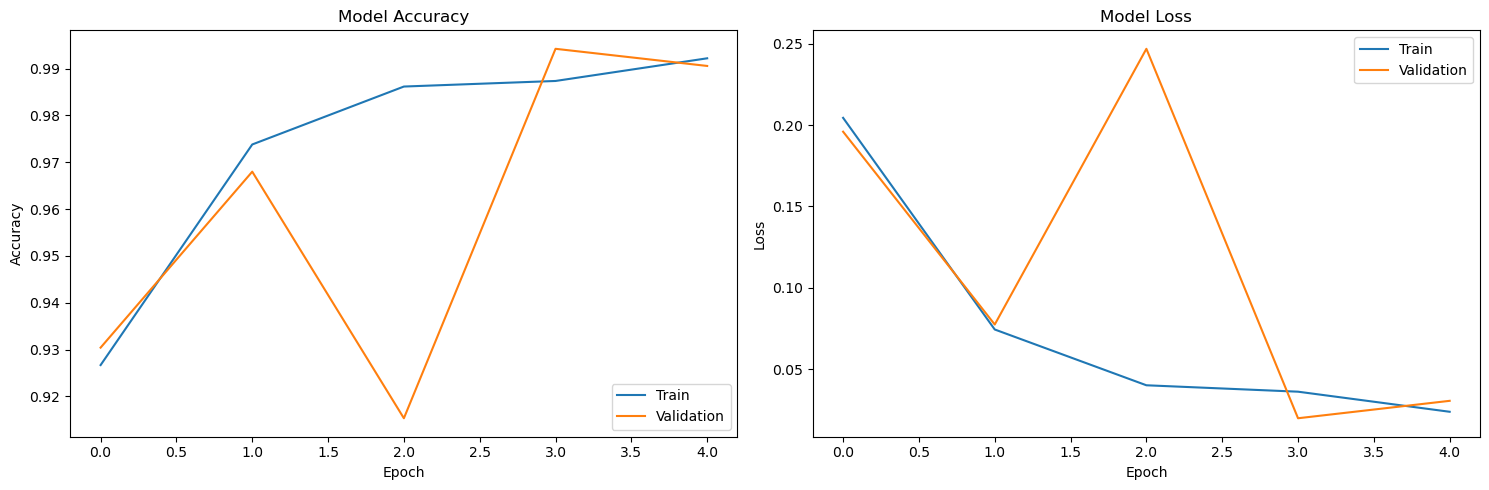

In [26]:
# training history
plot_training_history(history)

In [27]:
# model evaluation
print("\nEvaluating model on test dataset:")
evaluation = model.evaluate(test_dataset)
print(f"Test Loss: {evaluation[0]:.4f}")
print(f"Test Accuracy: {evaluation[1]:.4f}")



Evaluating model on test dataset:
709/709 [==============================] - 17s 24ms/step - loss: 0.0306 - accuracy: 0.9906
Test Loss: 0.0306
Test Accuracy: 0.9906


1/1 [==============================] - 0s 281ms/step


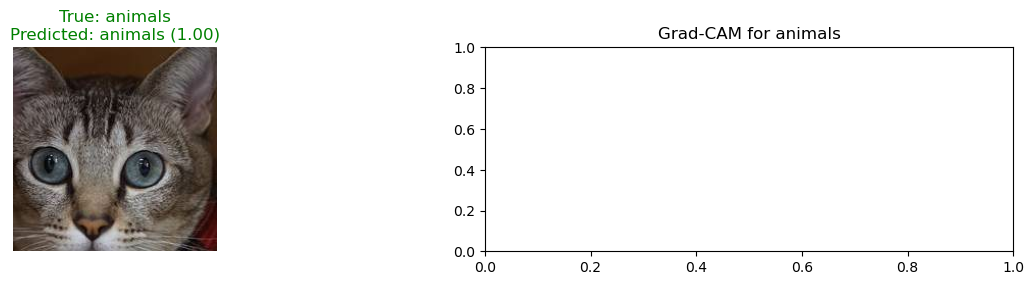

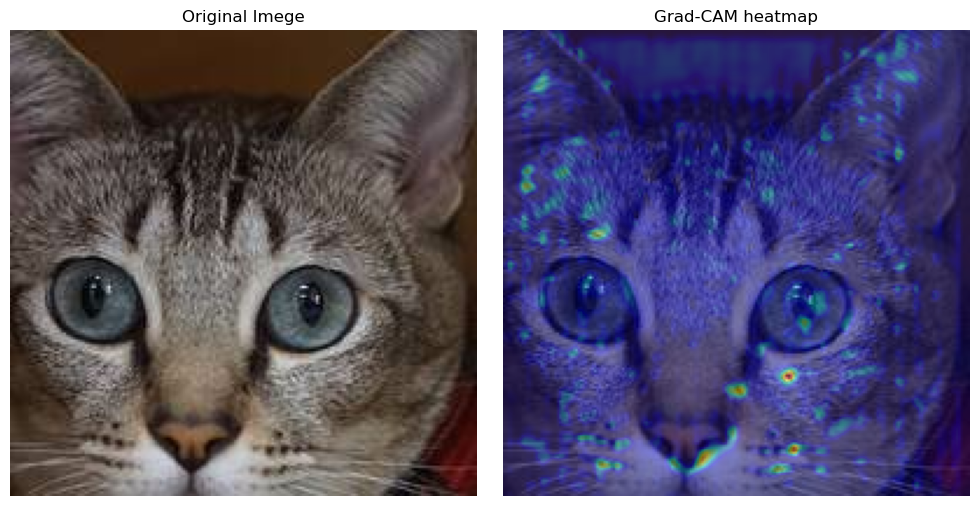

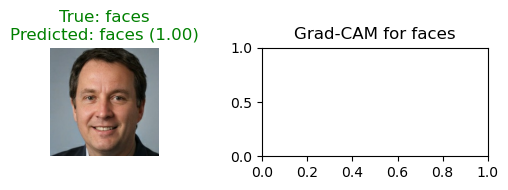

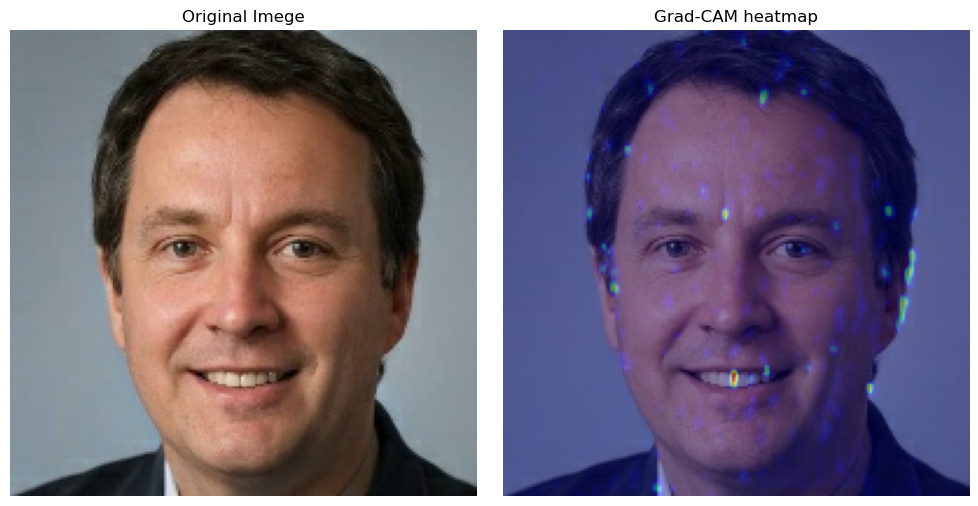

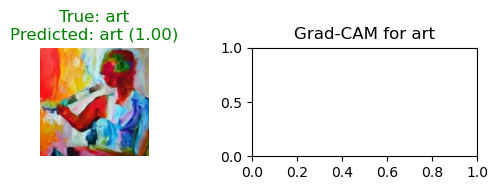

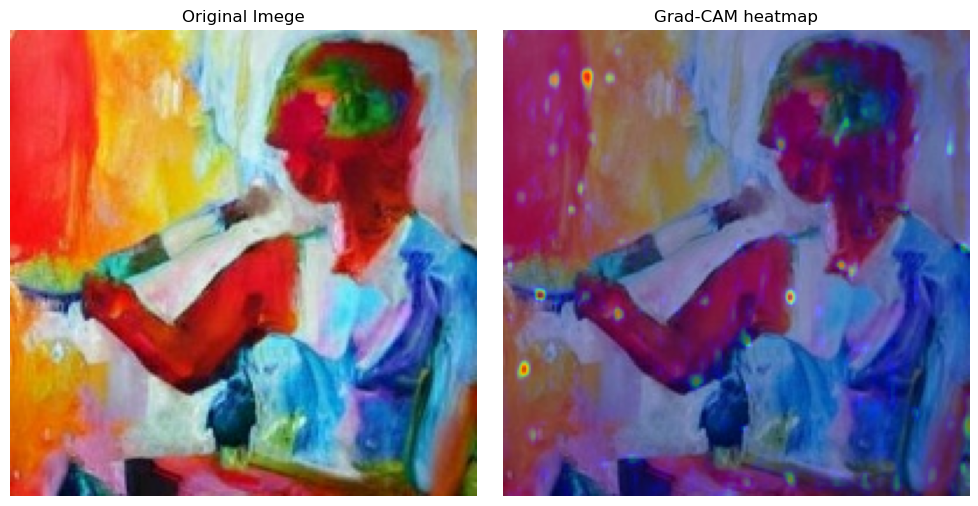

<Figure size 640x480 with 0 Axes>

In [ ]:
def visualize_model_predictions(model, test_dataset, class_names, num_samples=5):
    """
    Visualizes model predictions and explanations for test samples.
    
    Parameters:
        model: Trained model
        test_dataset: Test dataset
        class_names: List of class names
        num_samples: Number of samples to visualize
    """
    images_seen = 0
    test_images, test_labels = [], []
    
    for image_batch, label_batch in test_dataset:
        for img, lbl in zip(image_batch.numpy(), label_batch.numpy()):
            test_images.append(img)
            test_labels.append(lbl)
            images_seen += 1
            if images_seen >= num_samples:
                break
        if images_seen >= num_samples:
            break
    

    predictions = model.predict(np.array(test_images))
    
    plt.figure(figsize=(15, 3*num_samples))
    
    for i in range(num_samples):
        true_label = np.argmax(test_labels[i])
        pred_label = np.argmax(predictions[i])
        confidence = predictions[i][pred_label]
        
        plt.subplot(num_samples, 2, 2*i+1)
        plt.imshow(test_images[i])
        
        title_color = 'green' if true_label == pred_label else 'red'
        plt.title(f"True: {class_names[true_label]}\nPredicted: {class_names[pred_label]} ({confidence:.2f})", 
                  color=title_color)
        plt.axis('off')
        
        last_conv_layer = None
        for layer in reversed(model.layers):
            if isinstance(layer, layers.Conv2D):
                last_conv_layer = layer.name
                break
        
        plt.subplot(num_samples, 2, 2*i+2)
        plt.title(f"Grad-CAM for {class_names[pred_label]}")
        plot_gradcam(model, test_images[i], pred_label, last_conv_layer)
    
    plt.tight_layout()
    plt.show()

visualize_model_predictions(model, test_dataset, class_names, num_samples=3)